In [1]:
language = 'pt'

# 1. Gravação de Áudio Com Python (e Um pouco de JavaScript)

In [16]:
# Referência: https://gist.github.com/korakot/c21c3476c024ad6d56d5f48b0bca92be

from IPython.display import Audio, display, Javascript
from google.colab import output
from base64 import b64decode

# Código JavaScript para gravar áudio do usuário usando a "MediaStream Recording API"
RECORD = """
const sleep  = time => new Promise(resolve => setTimeout(resolve, time))
const b2text = blob => new Promise(resolve => {
  const reader = new FileReader()
  reader.onloadend = e => resolve(e.srcElement.result)
  reader.readAsDataURL(blob)
})
var record = time => new Promise(async resolve => {
  stream = await navigator.mediaDevices.getUserMedia({ audio: true })
  recorder = new MediaRecorder(stream)
  chunks = []
  recorder.ondataavailable = e => chunks.push(e.data)
  recorder.start()
  await sleep(time)
  recorder.onstop = async ()=>{
    blob = new Blob(chunks)
    text = await b2text(blob)
    resolve(text)
  }
  recorder.stop()
})
"""

def record(sec=5):
  # Executa o código JavaScript para gravar o áudio
  display(Javascript(RECORD))
  # Recebe o áudio gravado como resultado do JavaScript
  js_result = output.eval_js('record(%s)' % (sec * 1000))
   # Decodifica o áudio em base64
  audio = b64decode(js_result.split(',')[1])
  # Salva o áudio em um arquivo
  file_name = 'request_audio.wav'
  with open(file_name, 'wb') as f:
    f.write(audio)
  # Retorna o caminho do arquivo de áudio (pasta padrão do Google Colab)
  return f'/content/{file_name}'

# Grava o áudio do usuário por um tempo determinado (padrão 5 segundos)
print('Ouvindo...\n')
record_file = record()

# Exibe o áudio gravado
display(Audio(record_file, autoplay=True))

Ouvindo...



<IPython.core.display.Javascript object>

# 2. Reconhecimento de Fala com Whisper (OpenAI) 🧠

In [4]:
!pip install git+https://github.com/openai/whisper.git -q

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [17]:
import whisper

# Selecione o modelo do Whisper que melhor atenda às suas necessidades:
# https://github.com/openai/whisper#available-models-and-languages
model = whisper.load_model("small")

# Transcreve o audio gravado anteriormente.
result = model.transcribe(record_file, fp16=False, language=language)
transcription = result["text"]
print(transcription)

 O que é a Lua?


# 3. Integração com a API do Gemini


In [18]:
import google.generativeai as genai
from google.colab import userdata
import os

# Configure a chave de API do Gemini usando a variável de ambiente 'GOOGLE_API_KEY'
# Certifique-se de que sua API Key esteja configurada nos segredos do Colab.
GOOGLE_API_KEY=userdata.get('GOOGLE_API_KEY')
genai.configure(api_key=GOOGLE_API_KEY)

# Inicializa o modelo Gemini
gemini_model = genai.GenerativeModel('gemini-2.5-flash')

# Envia uma requisição à API do Gemini usando o modelo 'gemini-pro'
# Lembrando que, a variável 'transcription' contém a transcrição do nosso áudio.
response = gemini_model.generate_content(transcription)

# Obtém a resposta gerada pelo Gemini
chatgemini_response = response.text
print(chatgemini_response)

A **Lua** é o **único satélite natural da Terra** e o corpo celeste mais próximo de nós. É o objeto mais brilhante no nosso céu noturno, depois do Sol.

Aqui estão as principais características e informações sobre a Lua:

1.  **Satélite Natural:** Orbita a Terra a uma distância média de aproximadamente 384.400 km.

2.  **Corpo Rochoso:** É um mundo sólido e rochoso, sem atmosfera significativa. Sua superfície é coberta por regolito (uma camada de poeira e fragmentos de rocha soltos) e é marcada por:
    *   **Crateras:** Formadas pelo impacto de meteoritos.
    *   **Mares lunares (Maria):** Grandes planícies escuras de basalto, formadas por antigas erupções vulcânicas (apesar do nome, não há água líquida nelas).
    *   **Montanhas e vales.**

3.  **Sem Atmosfera:** A ausência de uma atmosfera significa que não há ar para respirar, não há proteção contra radiação solar e meteoritos, e as temperaturas variam drasticamente: de cerca de +120°C durante o dia a -170°C à noite.

4.  **Não E

# 4. Sintetizando a Resposta do Chatgemini Como Voz (gTTS) 🔊

In [12]:
!pip install gTTS

In [19]:
from gtts import  gTTS

# Cria um objeto gTTS com a resposta gerada pelo Chatgemini e a língua que será sintetizada em voz (variável "language").
gtts_object = gTTS(text=chatgemini_response, lang=language, slow=False)

# Salva o áudio da resposta no arquivo especificado (pasta padrão do Google Colab)
response_audio = "/content/response_audio.wav"
gtts_object.save(response_audio)

# Reproduz o áudio da resposta salvo no arquivo
display(Audio(response_audio, autoplay=True))

# 5. Geração de Imagens com Stable Diffusion (via Diffusers) TESTE!!!

In [14]:
!pip install diffusers transformers accelerate torch -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.4/108.4 kB 6.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gtts 2.5.4 requires click<8.2,>=7.1, but you have click 8.3.2 which is incompatible.


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

StableDiffusionSafetyChecker LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/safety_checker
Key                                               | Status     |  | 
--------------------------------------------------+------------+--+-
vision_model.vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Gerando imagem para o prompt: ' O que é a Lua?'


  0%|          | 0/50 [00:00<?, ?it/s]

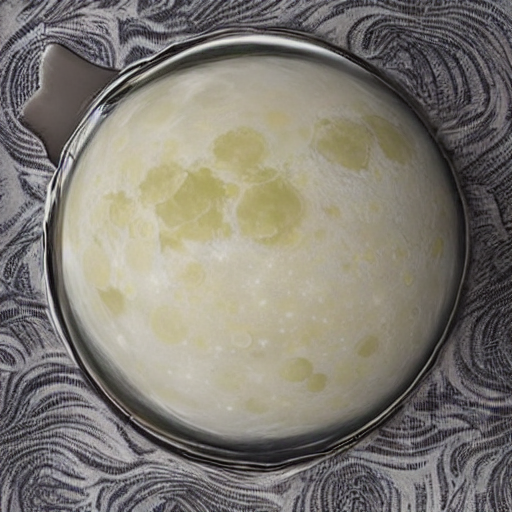

Imagem salva como: generated_image.png


In [23]:
from diffusers import StableDiffusionPipeline
import torch
from IPython.display import Image

# As imagens não são boas, mas é apenas um teste para ver se era possivel pegar o prompt direto do audio e ver se seria transformado em imagem,
# pesquisar como melhorar esta parte e devo atualizar em breve.

# Carregue o pipeline do Stable Diffusion. Este processo pode demorar um pouco.
# Usaremos um modelo menor e otimizado para testes, como 'runwayml/stable-diffusion-v1-5'.
pipeline = StableDiffusionPipeline.from_pretrained("runwayml/stable-diffusion-v1-5", torch_dtype=torch.float16)
pipeline = pipeline.to("cuda")

# Use a transcrição do áudio como prompt para a geração da imagem
prompt = transcription # Assume que 'transcription' contém o texto do áudio
print(f"Gerando imagem para o prompt: '{prompt}'")

# Gere a imagem
image = pipeline(prompt).images[0]

# Salve a imagem em um arquivo temporário
image_file = "generated_image.png"
image.save(image_file)

# Exiba a imagem
display(Image(filename=image_file))
print(f"Imagem salva como: {image_file}")